In [ ]:
# Clean up data

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', None)    # Show all rows
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.max_colwidth', None)# Show full content of each cell
pd.set_option('display.width', None) 

confounds_df = pd.read_csv('./adult/phenotype/confounders/confounders.tsv', sep='\t')
print(confounds_df.head())

   participant_id  age_started_using_nicotine_products  \
0            5009                                  NaN   
1          891982                                  NaN   
2          502326                                  NaN   
3          311375                                  NaN   
4          356704                                  NaN   

   age_stopped_using_nicotine_products airway_surgery_reconstruction  \
0                                  NaN                           NaN   
1                                  NaN                           NaN   
2                                  NaN                           NaN   
3                                  NaN                           NaN   
4                                  NaN                           NaN   

  alcohol_amt_v2          alcohol_drinks alcohol_freq_v2 alcohol_today_v2  \
0            NaN  Never in the past year             NaN              NaN   
1            NaN                     NaN             NaN        

In [2]:
total_rows = len(confounds_df)
valid_counts = confounds_df.count()
nan_counts_calculated = total_rows - valid_counts

print(valid_counts)
#print(nan_counts_calculated)

participant_id                                                     903
age_started_using_nicotine_products                                 15
age_stopped_using_nicotine_products                                 11
airway_surgery_reconstruction                                       73
alcohol_amt_v2                                                      33
alcohol_drinks                                                     470
alcohol_freq_v2                                                     33
alcohol_today_v2                                                    33
alcohol_yn                                                         902
allergy_medications                                                 73
analgesics                                                          72
androgenic_steroids                                                 73
anti_anxiety_medication                                             73
antibiotics                                                         73
antich

In [5]:
dx_controls_df = pd.read_csv('./adult/phenotype/diagnosis/control.tsv', sep='\t')

print(dx_controls_df.head())
#print(dx_controls_df.dtypes.to_string())
print(len(dx_controls_df))

   participant_id diagnosis_c_ac
0          146928             No
1           78823            Yes
2          698881             No
3          375532             No
4          377429             No
148


In [7]:
dx_copd_asthma_df = pd.read_csv('./adult/phenotype/diagnosis/copd_and_asthma.tsv', sep='\t')
dx_as_df = pd.read_csv('./adult/phenotype/diagnosis/airway_stenosis.tsv', sep='\t')
dx_cough_df = pd.read_csv('./adult/phenotype/diagnosis/unexplained_chronic_cough.tsv', sep='\t')

#print(dx_copd_asthma_df.head())
print(len(dx_copd_asthma_df))
#print(dx_as_df.head())
print(len(dx_as_df))
#print(dx_cough_df.head())
print(len(dx_cough_df))

9
138
41


In [9]:
demo_df = pd.read_csv('./adult/phenotype/demographics/demographics.tsv', sep='\t')

print(demo_df.dtypes.to_string())
print(len(demo_df))

participant_id                     int64
children                          object
cognition                         object
colorblind                        object
country                           object
demographics_duration            float64
demographics_session_id           object
edu_level                         object
ethnicity                         object
sex_at_birth                      object
grandparent                       object
hearing                           object
household_count                  float64
household_income_usa              object
housing_status                    object
independent_living                object
live_by_yourself                  object
mobility                          object
other_live_with                   object
parent                            object
primary_transportation            object
roommate                          object
self_care                         object
sex_assigned_at_birth             object
sexual_orientati

In [11]:
# Define groups with string labels
df_list = [
    dx_controls_df[['participant_id']].assign(disease_status="Control"),
    dx_copd_asthma_df[['participant_id']].assign(disease_status="COPD_Asthma"),
    dx_as_df[['participant_id']].assign(disease_status="AS"),
    dx_cough_df[['participant_id']].assign(disease_status="Cough")
]

# Combine everything
new_df = pd.concat(df_list, ignore_index=True)

# Recommended: Remove duplicates if a participant appears in multiple groups
# new_df = new_df.drop_duplicates(subset=['participant_id'])

print(new_df['disease_status'].value_counts())

disease_status
Control        148
AS             138
Cough           41
COPD_Asthma      9
Name: count, dtype: int64


In [13]:
#new_df.to_csv('participant_id_list.tsv', sep='\t', index=False)

In [15]:
# df_list = [
#     dx_controls_df[['participant_id']].assign(disease_status=0),
#     dx_copd_asthma_df[['participant_id']].assign(disease_status=1),
#     dx_as_df[['participant_id']].assign(disease_status=1),
#     dx_cough_df[['participant_id']].assign(disease_status=1)
# ]

# # Combine everything into one
# full_df = pd.concat(df_list, ignore_index=True)

# # Recommended: Remove duplicates if a person is in multiple disease files
# # full_df = new_df.drop_duplicates(subset=['participant_id'])

# print(full_df['disease_status'].value_counts())

In [17]:
# full_df.to_csv('participant_list_disease.tsv', sep='\t', index=False)

In [19]:
# Select the specific columns
cols_to_add = demo_df[['participant_id', 'age', 'sex_at_birth']]

# Merge
new_df = new_df.merge(cols_to_add, on='participant_id', how='left')

In [21]:
# Select the specific columns
cols_to_add_2 = confounds_df[['participant_id', 'seasonal_allergies']]

# Merge
new_df = new_df.merge(cols_to_add_2, on='participant_id', how='left')

In [23]:
print(new_df.head())
print(new_df.dtypes.to_string())

   participant_id disease_status age sex_at_birth seasonal_allergies
0          146928        Control  36         Male                 No
1           78823        Control  51       Female                 No
2          698881        Control  28       Female                Yes
3          375532        Control  20         Male                 No
4          377429        Control  76       Female                NaN
participant_id         int64
disease_status        object
age                   object
sex_at_birth          object
seasonal_allergies    object


In [25]:
new_df.to_csv('participant_list_full.tsv', sep='\t', index=False)

In [77]:
# ============================================
# 0) Imports
# ============================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score


# ============================================
# 1) Load data (TSV)
# ============================================

feat = pd.read_csv('./adult/features/static_features.tsv', sep='\t')
demo = pd.read_csv('./participant_list_full.tsv', sep="\t")

demo = demo[[
    "participant_id",
    "disease_status",
    "age",
    "sex_at_birth",
    "seasonal_allergies"
]].copy()


# ============================================
# 2) Merge
# ============================================

df = feat.merge(demo, on="participant_id", how="inner")


# ============================================
# 3) Clean types
# ============================================

# acoustic columns
feature_cols = [c for c in feat.columns if c != "participant_id"]

for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["disease_status"] = df["disease_status"].astype("category")
df["sex_at_birth"] = df["sex_at_birth"].astype("category")
df["seasonal_allergies"] = df["seasonal_allergies"].astype("category")

df = df.dropna(subset=["disease_status"])


# ============================================
# 4) Aggregate per participant
# ============================================

feat_agg = df.groupby("participant_id")[feature_cols].mean().reset_index()
demo_agg = df.groupby("participant_id")[[
    "disease_status",
    "age",
    "sex_at_birth",
    "seasonal_allergies"
]].first().reset_index()

df_part = feat_agg.merge(demo_agg, on="participant_id", how="inner")

print("Participants:", df_part.shape[0])


# ============================================
# 5) Encode outcome
# ============================================

df_part["disease_status"] = df_part["disease_status"].astype("category")
df_part["disease_code"] = df_part["disease_status"].cat.codes

y = df_part["disease_code"].to_numpy()


# ============================================
# 6) PCA → PC1–PC5 (with imputation)
# ============================================

X_raw = df_part[feature_cols].to_numpy(dtype=float)

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_clean = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_clean)

pca = PCA(n_components=5, random_state=0)
X_pc = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))


# ============================================
# 7) ML (PC1–PC5 only)
# ============================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

scores = []

for train_idx, test_idx in skf.split(X_pc, y):
    pipe.fit(X_pc[train_idx], y[train_idx])
    pred = pipe.predict(X_pc[test_idx])
    scores.append(balanced_accuracy_score(y[test_idx], pred))

print("Balanced Accuracy (PC1–PC5):")
print("Mean:", np.mean(scores))
print("Std:", np.std(scores))

Participants: 336
Explained variance: [0.16536021 0.11146665 0.07736362 0.0741964  0.06487295]
Cumulative: [0.16536021 0.27682686 0.35419048 0.42838688 0.49325983]
Balanced Accuracy (PC1–PC5):
Mean: 0.40006841817186645
Std: 0.008540142588311265


In [73]:
# ============================================
# Model 2: PC1–PC5 + demographics
# ============================================

import pandas as pd

X_demo = pd.get_dummies(
    df_part[["age", "sex_at_birth", "seasonal_allergies"]],
    drop_first=True
).to_numpy()

X_pc_demo = np.column_stack([X_pc, X_demo])

scores = []
for tr, te in skf.split(X_pc_demo, y):
    pipe.fit(X_pc_demo[tr], y[tr])
    pred = pipe.predict(X_pc_demo[te])
    scores.append(balanced_accuracy_score(y[te], pred))

print("\nBalanced Accuracy (PC1–PC5 + demographics):")
print("Mean:", np.mean(scores))
print("Std:", np.std(scores))


# ============================================
# Model 3: Demographics only
# ============================================

scores = []
for tr, te in skf.split(X_demo, y):
    pipe.fit(X_demo[tr], y[tr])
    pred = pipe.predict(X_demo[te])
    scores.append(balanced_accuracy_score(y[te], pred))

print("\nBalanced Accuracy (demographics only):")
print("Mean:", np.mean(scores))
print("Std:", np.std(scores))


Balanced Accuracy (PC1–PC5 + demographics):
Mean: 0.431665982484948
Std: 0.06176853191085915

Balanced Accuracy (demographics only):
Mean: 0.36078384418901666
Std: 0.021003442257560928


In [ ]:
"""
Using PC1–PC5 alone, the model achieved a balanced accuracy of ~0.40, indicating moderate disease-discriminative 
signal in the dominant acoustic variance. Adding demographics increased performance to ~0.43, suggesting that 
age and sex contribute additional predictive information beyond acoustics. Demographics alone achieved ~0.36, 
confirming that a substantial portion of disease separability is demographic rather than purely acoustic. 
Overall, acoustic PCs provide meaningful signal, but demographic structure explains a nontrivial fraction 
of classification performance, indicating partial confounding rather than purely acoustic disease separation.
"""

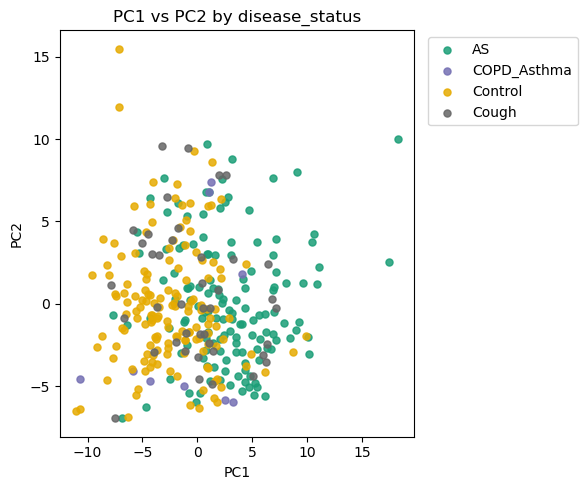

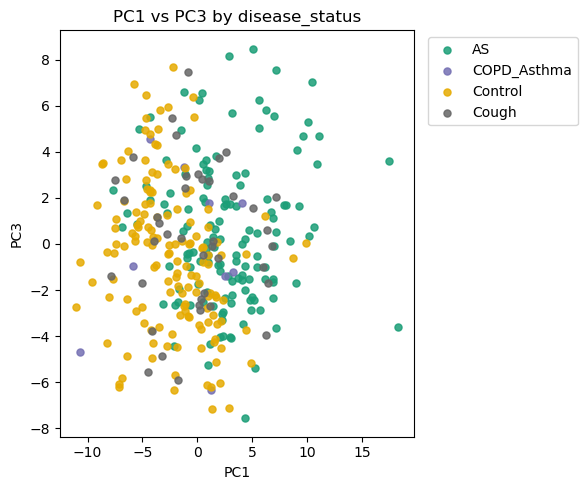

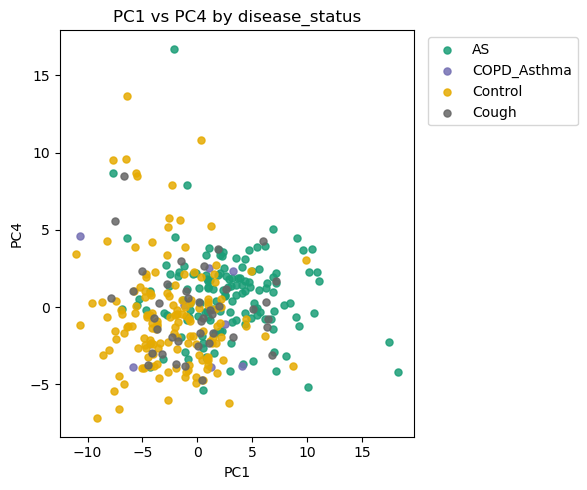

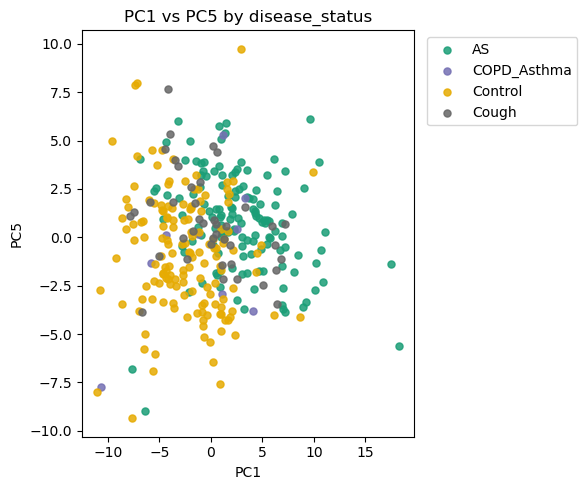

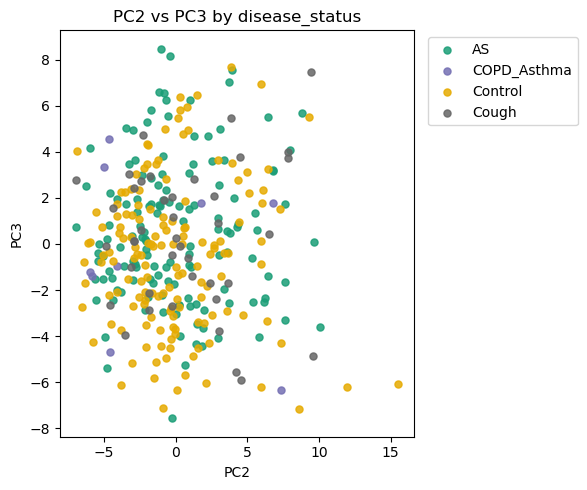

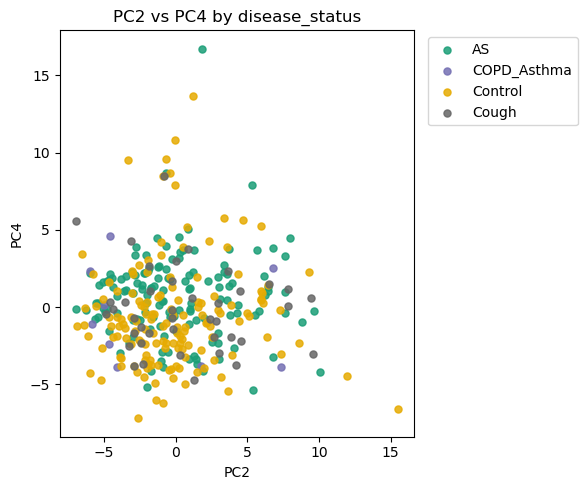

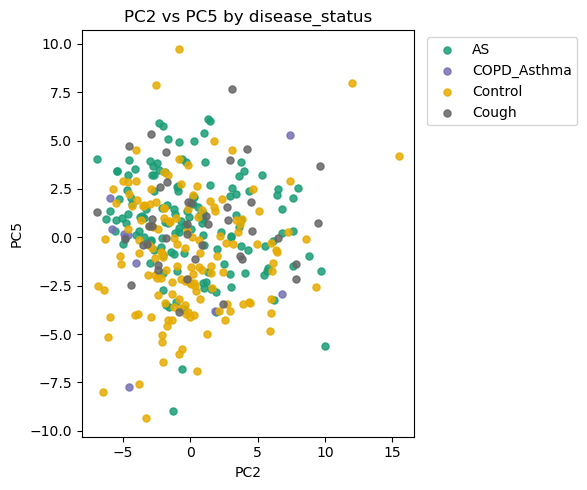

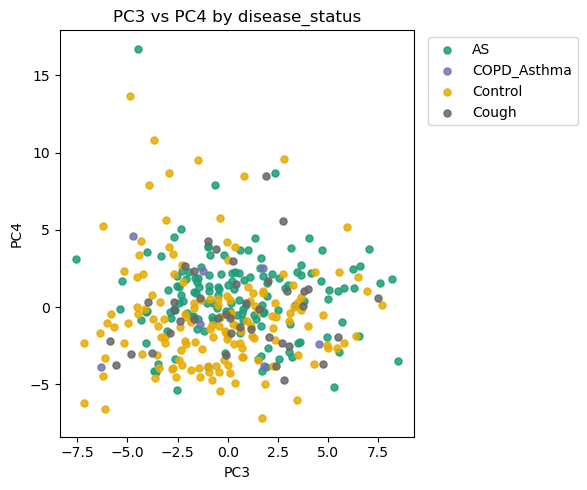

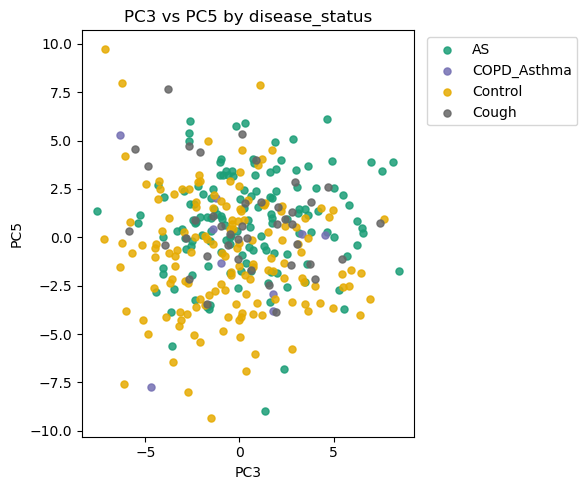

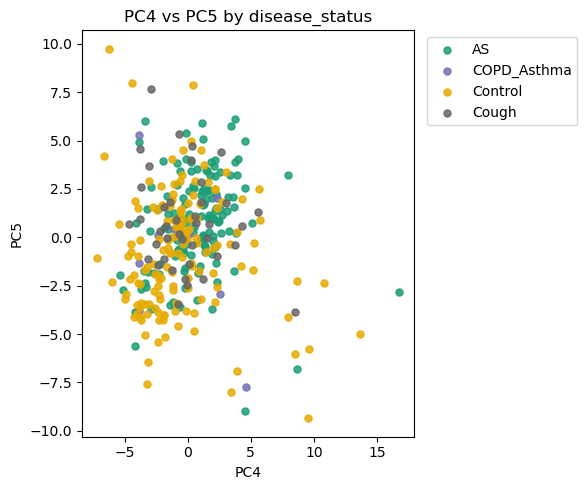

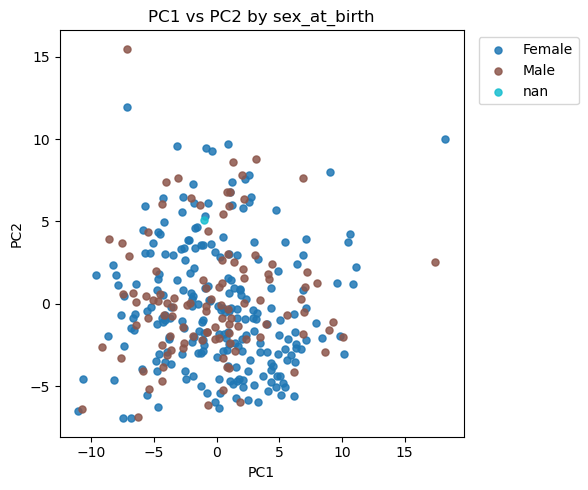

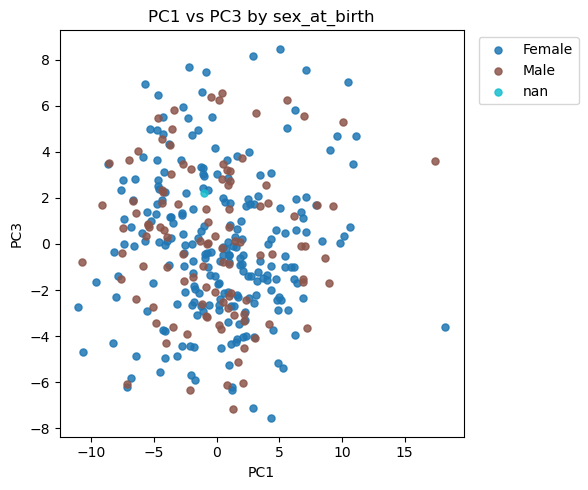

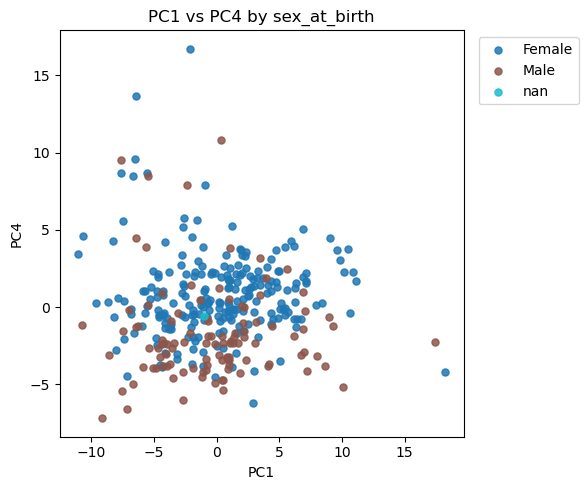

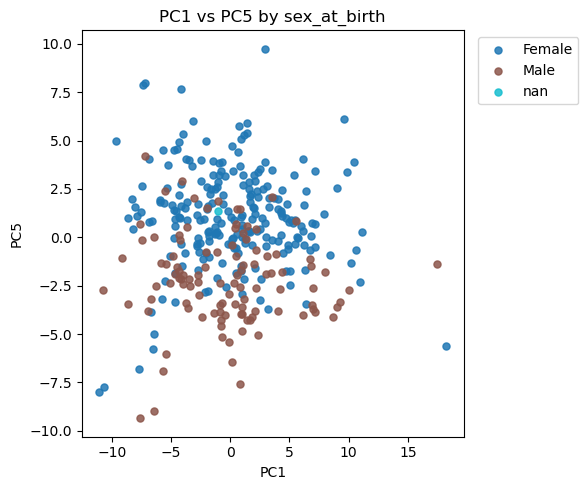

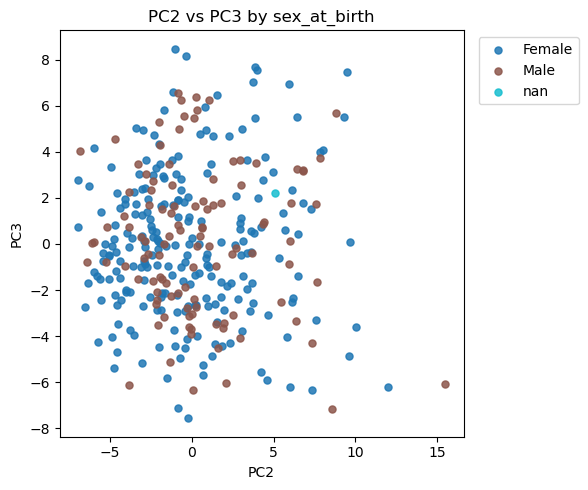

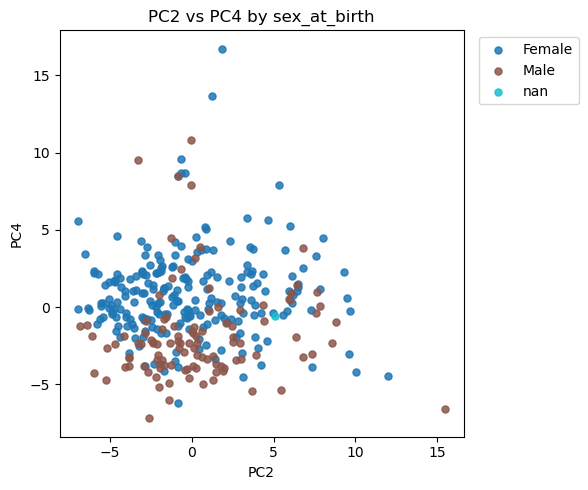

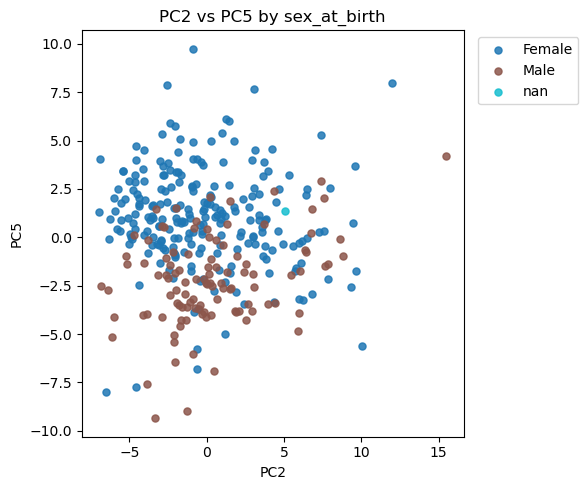

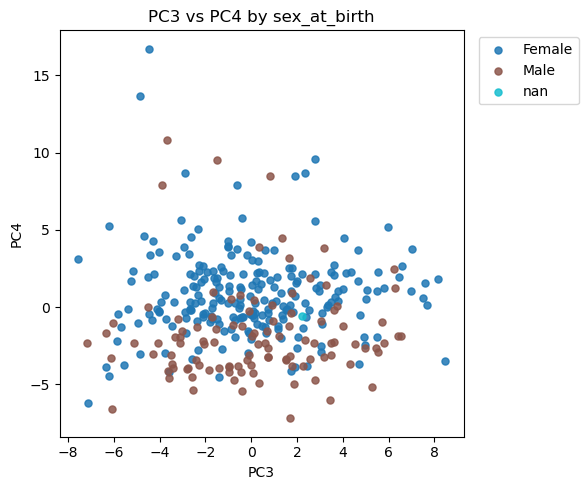

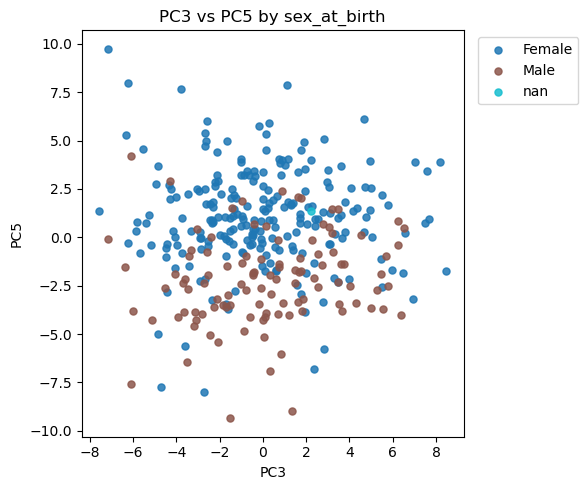

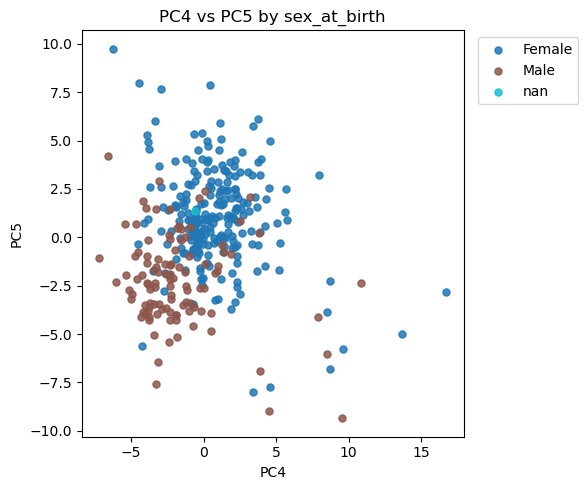

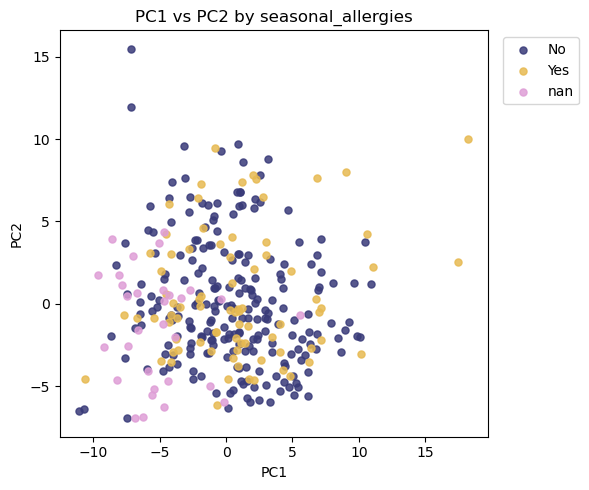

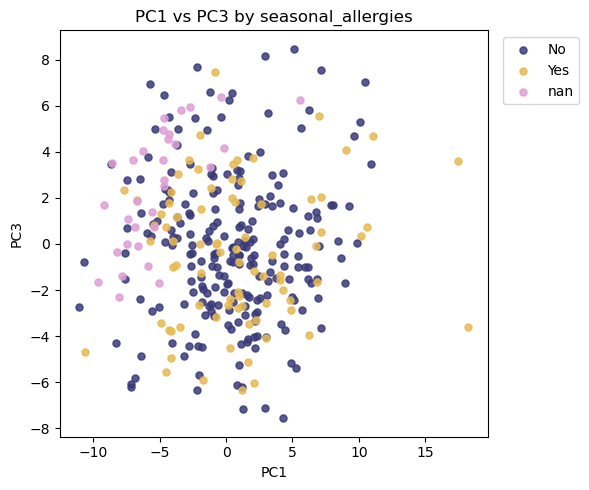

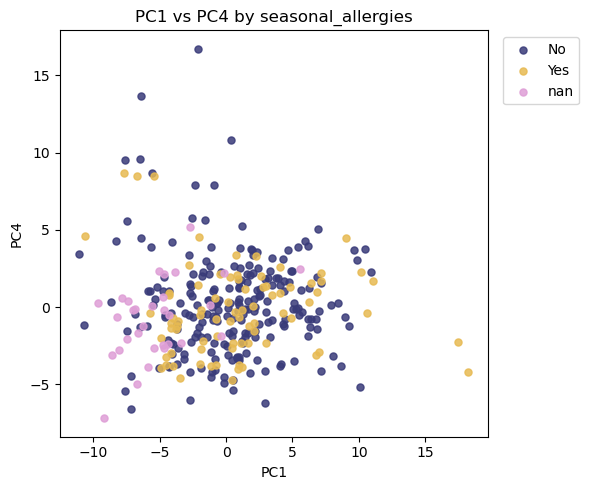

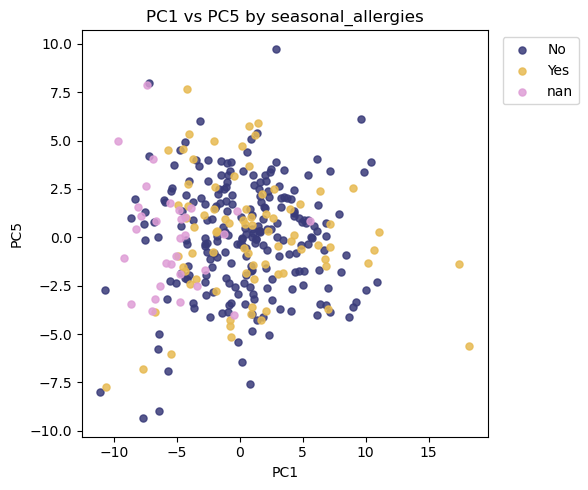

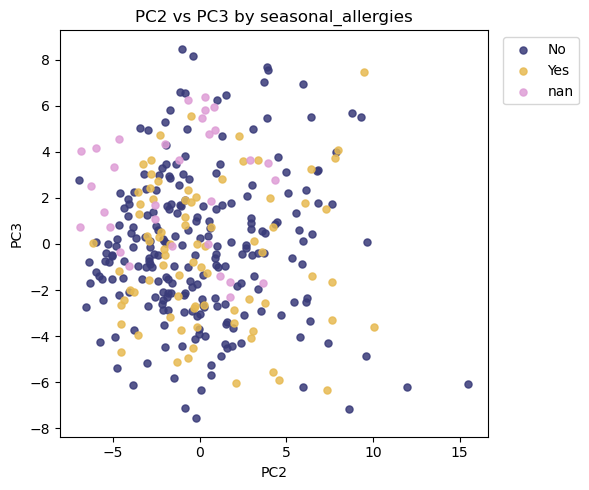

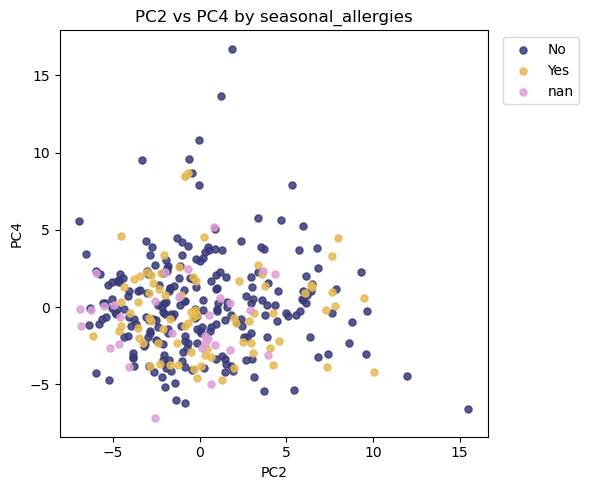

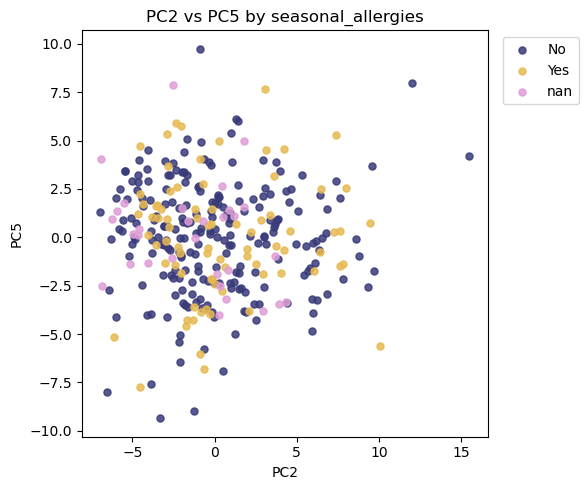

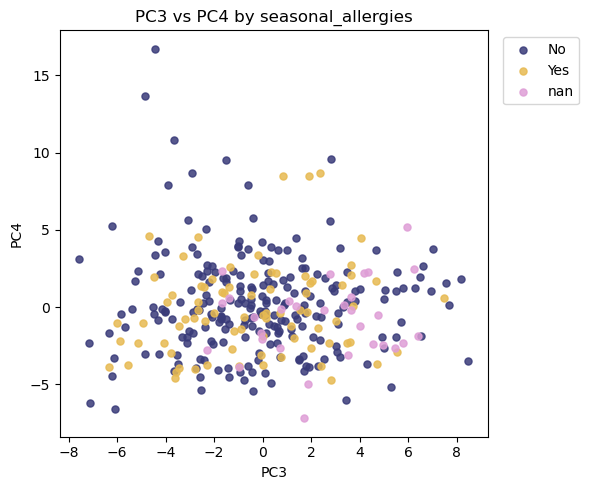

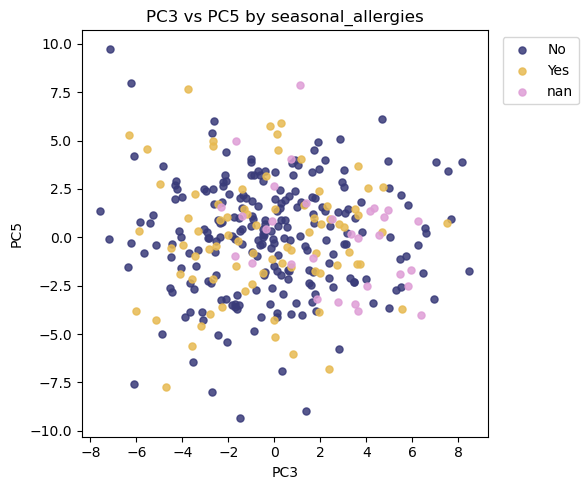

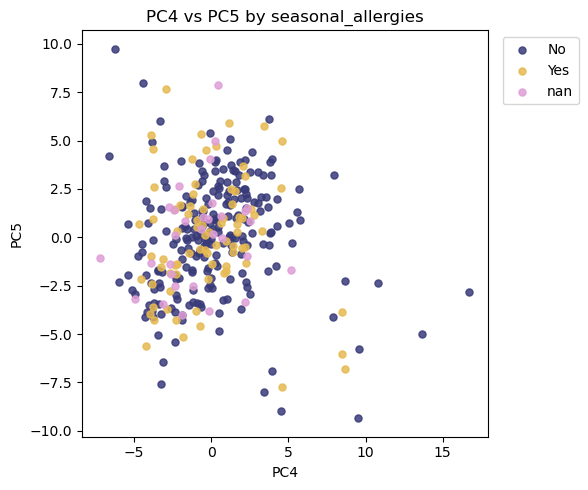

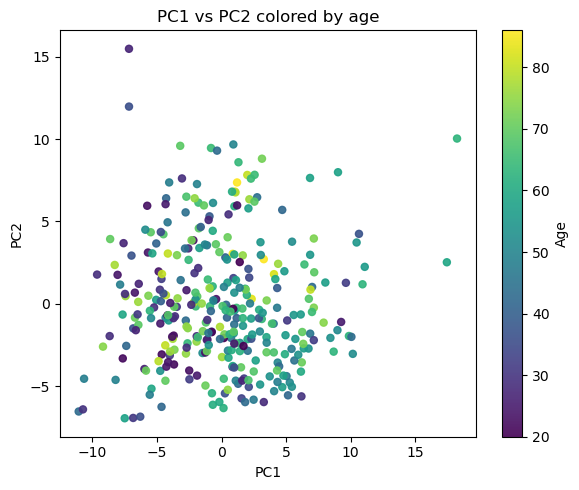

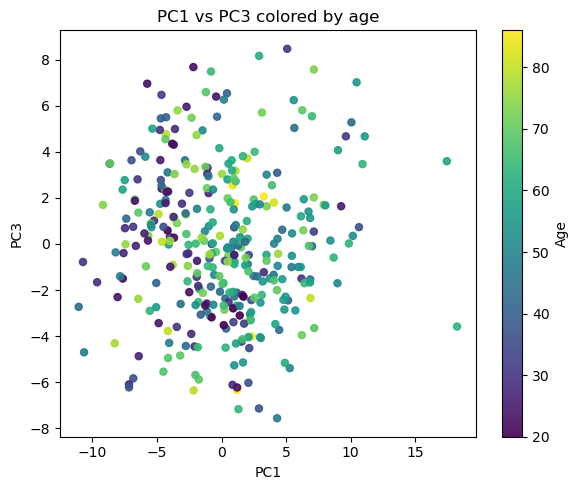

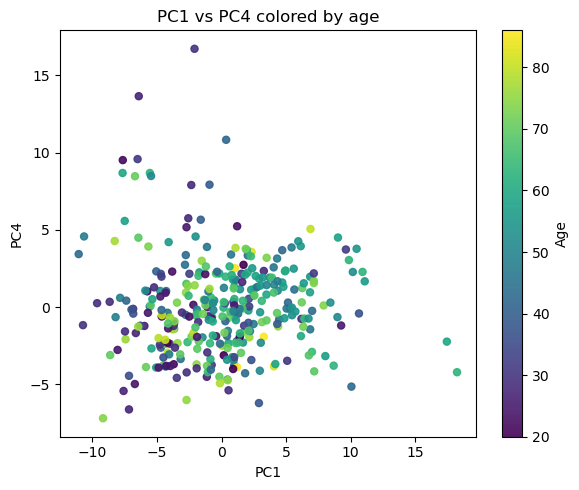

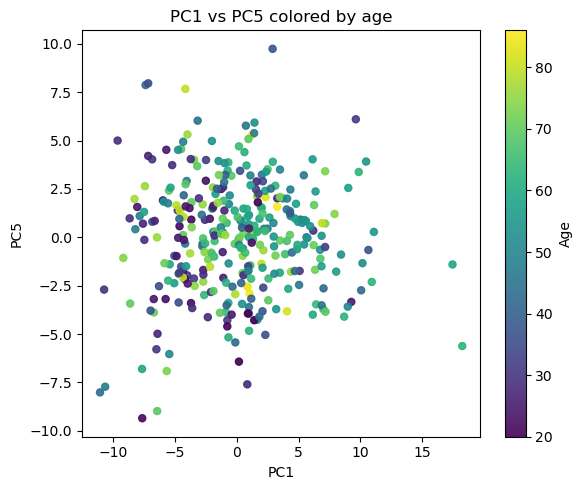

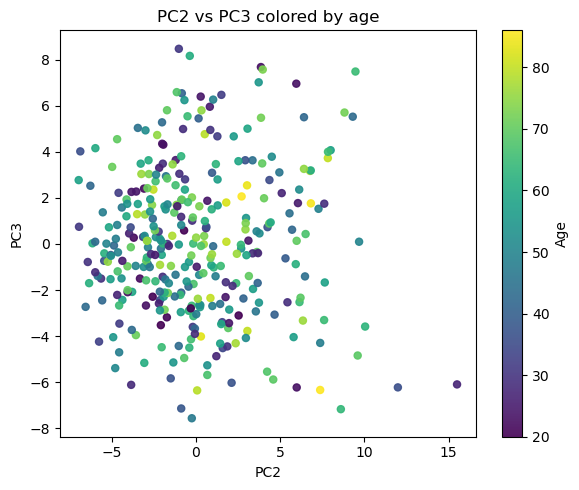

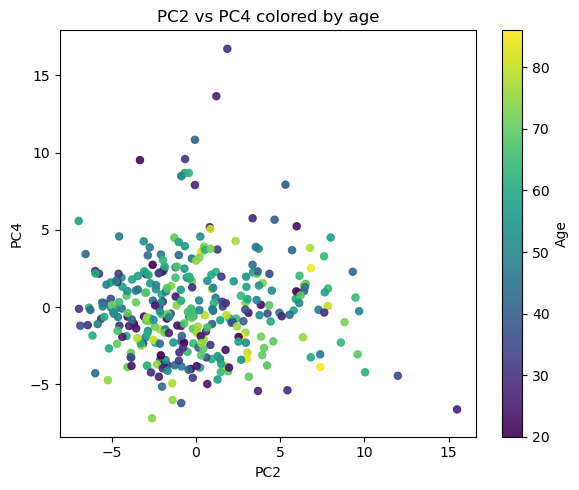

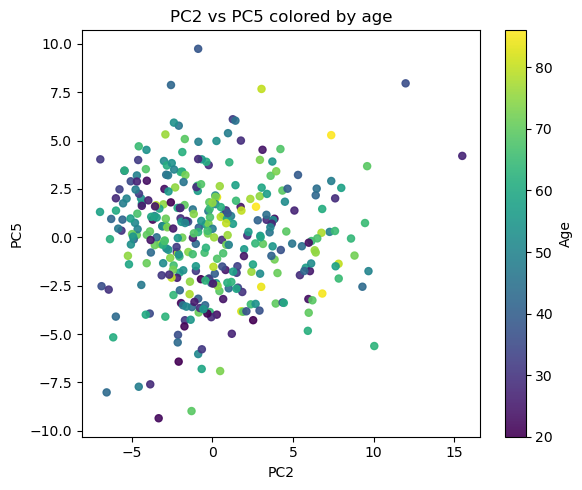

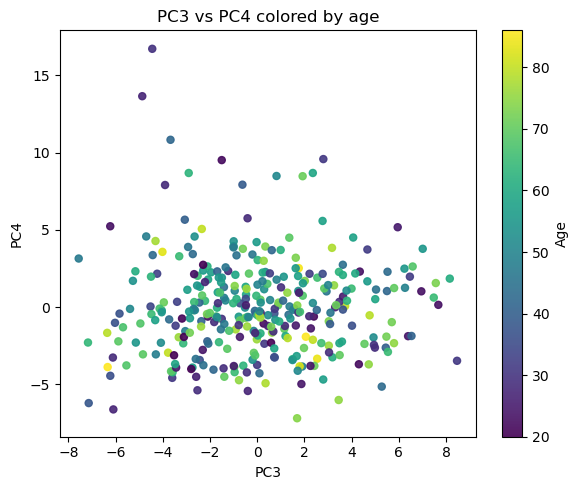

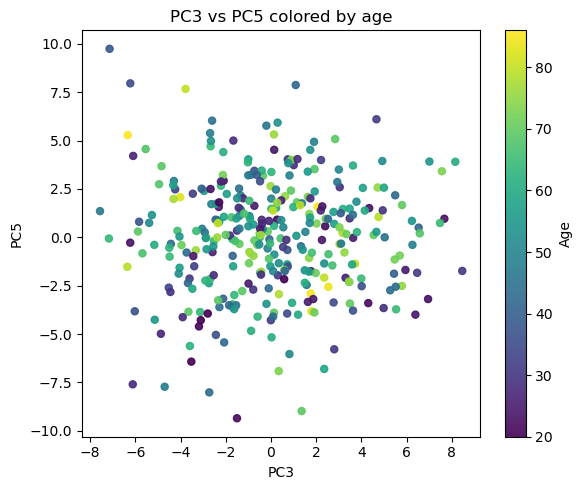

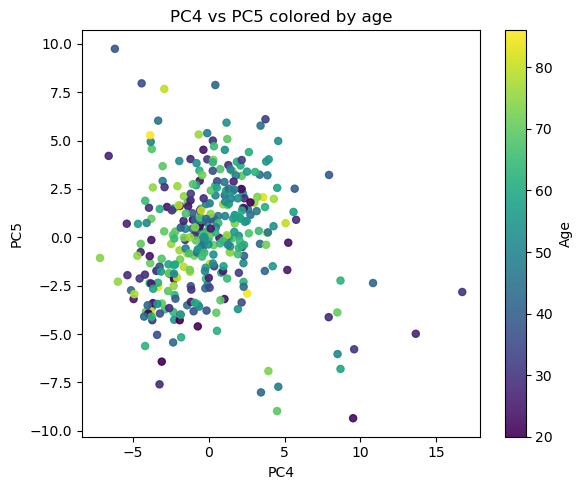

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import itertools
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

# Assumes you already have:
# - df_part (participant-level)
# - X_pc (numpy array shape [n, 5])

pdf = PdfPages("PCA_plots.pdf")

# Save every figure automatically when it's shown
import matplotlib.pyplot as plt
_original_show = plt.show

def save_and_show(*args, **kwargs):
    pdf.savefig(plt.gcf())
    _original_show(*args, **kwargs)

plt.show = save_and_show

pcs = ["PC1","PC2","PC3","PC4","PC5"]
pairs = list(itertools.combinations(range(5), 2))

# --- helpers ---
def colors_for_categories(categories, cmap_name="tab20"):
    cats = list(pd.Index(categories).astype(str))
    cmap = mpl.colormaps.get_cmap(cmap_name)
    # spread colors across the colormap
    denom = max(1, len(cats) - 1)
    return {c: cmap(i / denom) for i, c in enumerate(cats)}

def scatter_cat(i, j, series, title, cmap_name):
    s = series.astype(str).fillna("MISSING")
    cats = sorted(s.unique())
    col = colors_for_categories(cats, cmap_name)

    plt.figure(figsize=(6,5))
    for c in cats:
        m = (s == c).to_numpy()
        plt.scatter(X_pc[m, i], X_pc[m, j], s=26, alpha=0.85, color=col[c], label=c)

    plt.xlabel(pcs[i])
    plt.ylabel(pcs[j])
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()

def scatter_age(i, j):
    plt.figure(figsize=(6,5))
    sc = plt.scatter(X_pc[:, i], X_pc[:, j], c=df_part["age"], cmap="viridis", s=26, alpha=0.9)
    plt.colorbar(sc, label="Age")
    plt.xlabel(pcs[i])
    plt.ylabel(pcs[j])
    plt.title(f"{pcs[i]} vs {pcs[j]} colored by age")
    plt.tight_layout()
    plt.show()

# --- disease ---
for i, j in pairs:
    scatter_cat(i, j, df_part["disease_status"],
                f"{pcs[i]} vs {pcs[j]} by disease_status",
                "Dark2") 

# --- sex ---
for i, j in pairs:
    scatter_cat(i, j, df_part["sex_at_birth"],
                f"{pcs[i]} vs {pcs[j]} by sex_at_birth",
                "tab10") 

# --- allergies ---
for i, j in pairs:
    scatter_cat(i, j, df_part["seasonal_allergies"],
                f"{pcs[i]} vs {pcs[j]} by seasonal_allergies",
                "tab20b")

# --- age (continuous) ---
for i, j in pairs:
    scatter_age(i, j)

pdf.close()

In [ ]:
"""
The first principal component (PC1) explains approximately 16.5% of the total variance in the acoustic 
feature space, while PC2 explains an additional 11.1%, meaning the first two components together capture 
about 27.7% of overall variability. Expanding to PC1–PC5 increases the cumulative explained variance to 
approximately 49.3%, indicating that five components account for roughly half of the total acoustic variation. 
This suggests that the dominant structure of the feature space is moderately low-dimensional, but a substantial 
portion of variability remains distributed across higher-order components. For visualization, PC1–PC2 plots 
represent only about one quarter of the total variance, whereas PC1–PC5 provide a more comprehensive but 
still compressed representation of the acoustic feature space suitable for downstream modeling.
"""